In [1]:
import matplotlib.pyplot as plt
import numpy as np

from bracket import JointIntervalFinder

x1, x2: -0.013258705970818878 -0.0010150342034856335
Num. iterations: 4


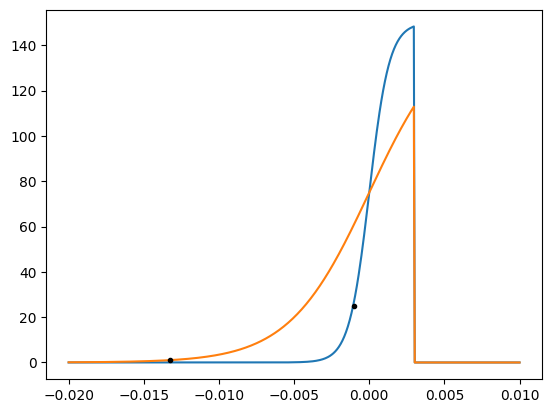

In [4]:
# Define your f(x, y) (expensive); here’s a toy bell/sigmoid hybrid for testing:
def f_demo(x, y):
    # bell centered at c(y), width s(y), height h(y), clipped to >=0
    c = 2.0 + 0.5*y
    s = 1.2 + 0.1*y
    h = 1.5 + 0.2*y
    val = h * np.exp(-0.5*((x-c-y)/s)**2)
    # add a shallow sigmoid tail to mimic monotone saturation possibility
    val += 0.4/(1.0 + np.exp(-(x - (c-2.0))))
    return val

def f_sigmoid(x, y):
    rmax = 150
    xc = 0
    xmax = 0.003
    k = 1500
    #r = rmax / (1 + k * np.exp(-(x - xc + y / 2) * (k / (1 + y))))
    r = rmax / (1 + np.exp(-(x - xc) * (k / (1 + y * 100))))
    r *= (x < xmax)
    return r

r1, r2 = 1, 25
y1, y2 = 0, 0.03

x10, x20 = -0.01, 0.01

#f = f_demo
f = f_sigmoid

k = 1

# user loop
finder = JointIntervalFinder(
    y1=y1, y2=y2,
    r1=r1, r2=r2,
    x1_start=(x10 / k),
    x2_start=(x20 / k),
    N=10,
    tol_frac=0.05,
    max_iters=20,
    x2_mode="y1_ge",
)

n_iter = 0
while not finder.is_done():
    xs = finder.suggest_x_values()
    # compute f1,f2 elsewhere (your batch evaluator):
    f1 = f(xs * k, finder.y1)
    f2 = f(xs * k, finder.y2)
    finder.process_probe_result(xs, f1, f2)
    n_iter += 1

x1_hat, x2_hat = finder.get_estimates()
print("x1, x2:", x1_hat, x2_hat)
print(f'Num. iterations: {n_iter}')

plt.figure()
#x = np.linspace(-10 / k, 10 / k, 500)
x = np.linspace(-0.02, 0.01, 500)
for y in [y1, y2]:
    plt.plot(x, f(x * k, y))
plt.plot([x1_hat, x2_hat], [r1, r2], 'k.')
